# **🧠 Introduction: How do diffusion models work?**

Most generative models (like GANs or VAEs) try to generate an image “all at once” from some random vector. Diffusion models do it completely differently – gradually, step by step.

The whole process consists of two main phases: the Forward Process and the Backward Process.

>*Note:* The tutorial is based on the Hugging Face course:
[Diffusion Course](https://huggingface.co/learn/diffusion-course/unit0/1)

## ***1. Forward Process (Adding Noise / Forward Process)***

We take a clean, beautiful image (in our case, a butterfly 🦋) and start adding random noise (Gaussian noise) to it in small increments (steps).

- After 10 steps, the butterfly is a bit noisy.
- After 100 steps, you can barely see the wings.
- After 1000 steps, there is nothing left of the image but pure, random noise (television grain).

*This process is purely mathematical and fixed – we don't need any neural network for it. This planning is handled by a component called* **Scheduler**.

## ***2. Reverse Process (Denoising / Reverse Process)***

**This is where the real magic comes in.** If we could reverse this process – take pure noise and gradually remove noise from it – we could create a completely new image from pure chance!

The problem is that we don’t know exactly how to remove the noise. And that’s why we train a neural network (the **UNet** architecture).

**What exactly does the network learn?** > The network is not tasked with generating a bow tie. It is tasked with looking at a noisy image and **predicting what noise was added to the image at a given step**. When the network correctly estimates this noise, we subtract it from the image. This gives us a slightly cleaner image and we repeat this process a hundred times, perhaps, until we have a perfect bow tie.

## ***3. 🛠️ Building blocks Hugging Face*** `diffusers`

The `diffusers` library from Hugging Face, which we will be working with, breaks this complex system down into several elegant objects:

1. **Models:** Most often a neural network of the `UNet2DModel` type. It has the shape of the letter "U" - first it reduces the image (to understand the global structure), and then it enlarges it again (to calculate the details).
2. **Schedulers:** These control the mathematics behind adding noise during training and subtracting noise during generation.
3. **Pipelines:** A container that connects the model and the planner together so that the end user can simply call `pipe()` and get the finished image.


## ***4. 🎯 Our plan for this tutorial***

In this notebook, we'll first try out the finished image generation pipeline to see how amazing it works. Then we'll break down the training script, where we'll see:

- How to download the butterfly dataset.
- How to set up a scheduler for adding noise.
- How to define a UNet network.
- How to write the training loop itself.

At the end, we will be able to scale this process and share our trained models with the community.

## ***5. How does UNet work in diffusion models?***

In diffusion models, the neural network UNet has a specific task: **it is not tasked with generating a clean image**, but with predicting the noise that was added to the image at a given time step. 

The input to the network is a **noisy image** and information about the **current time step ($t$)**. The output is then an estimated noise map of the same size as the input image. 

The architecture has a characteristic **"U"** shape and consists of three main parts:

1. **Downsampling / Encoder:** Gradually reduces the spatial resolution of the image (e.g. using stepwise convolutions or pooling), but at the same time increases the number of channels (features). In this way, the network captures the global context and coarse features of the image.
2. **Bottleneck:** The lowest layer with the lowest resolution, where the deepest information processing occurs.
3. **Upsampling / Decoder:** Gradually restores the original image resolution (using transposed convolutions or upsampling) and reduces the number of channels.

### ***Key feature: Skip Connections***

Fine spatial details are lost during downscaling in the Encoder. That's why UNet uses **Skip Connections**, which copy detailed features from the Encoder directly to the corresponding layers in the Decoder. This allows the Decoder to perfectly combine global context (from the bottom of the "U") with detailed information (from the side via skip connections).

#### ***UNet Architecture & Diffusion Model Cycle (Graph in Markdown)***




```text
               PREVIOUS PROCESS (Forward Process)
  [ Clear image (x₀) ] --------> Adding noise (Scheduler) --------> [ Pure noise (x_T) ]
                                            |
                                            v
                                 REVERSE PROCESS (Training)
                                            |
  +-----------------------------------------+-----------------------------------------+
  |                                                                                   |
  |      [ Noisy image (x_t) ] + [ Time step (t) ]                                    |
  |                  |                                                                |
  |                  v                                                                |
  |            ============== NETWORK ARCHITECTURE UNet ==============                |
  |            |                                                     |                |
  |   ENCODER  | [Input: 32x32x3]                            [Exit]  |  DECODER       |
  |   (Down)   |     |                                          ^    |    (Up)        |
  |            |     v                                          |    |                |
  |            | [Distinction: 16x16] -- Skip Connection --> [16x16] |                |
  |            |     |                                          ^    |                |
  |            |     v                                          |    |                |
  |            | [Distinction: 8x8]  -- Skip Connection -->  [8x8]   |                |
  |            |     |                                          ^    |                |
  |            +-----+------------------------------------------+----+                |
  |                  |                                          |                     |
  |                  +----------> [ BOTTLENECK: 4x4 ] ----------+                     |
  |                                                                                   |
  |                                         |                                         |
  |                                         v                                         |
  |                             [ Predicted noise (ε_theta) ]                         |
  |                                         |                                         |
  |                                         v                                         |
  |                 Comparison: Calculation of Loss vs. Real Noise                    |
  +-----------------------------------------------------------------------------------+
  ```

#### ***How does this fit into the training cycle?***

1. **Noise sampling:** We take a clean image from our dataset and the scheduler adds random noise to it for a randomly selected time step $t$.
2. **Prediction:** UNet looks at this noisy image and tries to guess what noise has been added.
3. **Optimization:** Using MSE loss (mean square error), we compare the actual added noise with what UNet predicted. The network updates its weights so that it makes fewer errors next time.

During the **generation** (inference) itself, we start with complete noise and let UNet gradually predict and subtract noise in many steps until the final image is created from the "television graininess".

### ***6. 🧠 Grand Synthesis: Three Pillars of Modern Diffusion***

#### ***Pillar 1: Mathematical Core (Noise and Denoising)***

The foundation of everything is the ability to transform chaos into order. This process is driven by two components:

- **Forward Process:** Gradual and controlled destruction of the image by adding Gaussian noise. This step is performed by the **Scheduler** based on mathematical equations.
- **Reverse Process:** Gradual removal of noise step by step. This step cannot be done by mathematics alone - it is performed by a neural network **UNet**, which has been trained to estimate (predict) the exact shape of the added noise at each step.

#### ***Pillar 2: Conditioning (How to drive the model)***

If we let UNet denoise without any guidance, the model would generate a realistic image, but a completely random one every time (so-called *unconditional generation*). In order to generate what we want, we need to **condition** the model (enter the process with additional information):

- **Text conditioning:** A text prompt (e.g. *"Pixar style butterfly"*) is translated into numerical vectors (embeddings) using a text encoder. UNet perceives these vectors and denoises the pixel matrix so that the resulting shapes match the text input.
- **Image conditioning (IP-Adapter, ControlNet):** Instead of text (or next to it), we insert another image as a clue. The model then does not pull random things out of the noise, but copies the identity, pose or composition from our template.

#### ***Pillar 3: Adaptation and Architecture (Fine-tuning and Multi-Agents)***

The final pillar is how we adapt and scale these models for the real world:

- **LoRA and DreamBooth:** Methods that allow us to inject specific new knowledge (your face, your product) into the already finished "brain" of the model with minimal computing power requirements.
- **Mixture of Experts (MoE) & Agents:** The pinnacle of current technology (used in systems like Grok). Instead of a single network, we have a team of specialized experts. In addition, the conversational agent can modify the image iteratively (using Inpainting techniques), thus achieving enormous variability and interactivity.

### ***7. 🗺️ Theoretical Map: From Noise to Ready-Made Agent***

The following diagram shows how the individual layers of technologies theoretically build on each other:

```text
  🏢 APPLICATION LEVEL LAYER (Grok, Multi-Agent Systems, Iterative Editing)
     ▲  - It combines text, multiple image references, and chat for step-by-step editing.
     |
  🎛️ CONTROL & ADAPTATION LAYER (LoRA, DreamBooth, ControlNet, IP-Adapter)
     ▲  - It bends and controls the model to generate specific people, styles, and precise poses.
     |
  🧠 CONDITIONING LAYER (Text-to-Image / CLIP Embeddings)
     ▲  - It translates human input (text/images) into a language that the neural network understands.
     |
  🧱 MATHEMATICAL BASIS (What is explained now: UNet + Scheduler + Differential Noise)
        - A core that can take graininess (noise) and create clean pixels from it step by step.
```

#### ***Conclusion of the theoretical introduction***

In order to effectively work with the upper layers (creating custom agents, training LoRA adapters, or bending ControlNets), one must safely master the lowest layer – the **Mathematical Foundation**. One must understand how the tensor with noise passes through the **UNet** down to the bottleneck and back up again.

# ***Initial setup***

In [1]:
%pip install -qq -U diffusers datasets transformers accelerate ftfy pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,

In [2]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")
secret_value_1 = user_secrets.get_secret("user_email")
secret_value_2 = user_secrets.get_secret("user_name")
secret_value_3 = user_secrets.get_secret("WAB_LOGIN")

In [3]:
from huggingface_hub import login, HfApi, snapshot_download

if secret_value_0:
    login(token=secret_value_0, add_to_git_credential=False)
    print("✅ Hugging Face login successful.")
else:
    print("❌ Error: Token 'HF_TOKEN' not found in Colab Secrets!")

✅ Hugging Face login successful.


In [4]:
import os, glob
import subprocess

def set_git_config(email, name):
    try:
        # Setting global user.email
        subprocess.run(["git", "config", "--global", "user.email", email], check=True)
        #print(f"Git user.email set to: {email}")

        # Setting the global user.name
        subprocess.run(["git", "config", "--global", "user.name", name], check=True)
        #print(f"Git user.name set to: {name}")

        # Check settings (optional)
        email_output = subprocess.run(["git", "config", "--global", "user.email"], capture_output=True, text=True, check=True)
        name_output = subprocess.run(["git", "config", "--global", "user.name"], capture_output=True, text=True, check=True)
        #print(f"Check - Email: {email_output.stdout.strip()}")
        #print(f"Check - Name: {name_output.stdout.strip()}")

    except subprocess.CalledProcessError as e:
        print(f"Error while setting up Git configuration: {e}")

In [5]:
%%capture
!sudo apt -qq install git-lfs
!git config --global credential.helper store

In [6]:
user_email = secret_value_1
user_name = secret_value_2
#print(user_email, user_name)
set_git_config(user_email, user_name)

Finally, let's import the libraries we'll be using and define a few convenience functions which we'll use later in the notebook:

In [7]:
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from PIL import Image

In [8]:
def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5  # Map from (-1, 1) back to (0, 1)
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im

In [9]:
def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im

In [10]:
# Mac users may need device = 'mps' (untested)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ***🎓 Example 1: First contact with a finished Pipeline (DreamBooth)***

Before we start building our own model from scratch, let's show you what it's like to work with a ready-made, advanced system. This example uses the **[DreamBooth](https://dreambooth.github.io/)** method – a Stable Diffusion model, which the course authors took and specifically trained on just **5 photos** of a children's toy *"Mr Potato Head"*.

#### ***1. Load the generic Pipeline***

The code first imports the necessary `StableDiffusionPipeline` class and downloads the specific weights of the modified model directly from the Hugging Face Hub.

>Note: Because several gigabytes of data are being downloaded, we use the `torch.float16` data type (half precision) in the Google Colab environment, which dramatically saves GPU memory and speeds up the calculation.

In [11]:
from diffusers import StableDiffusionPipeline
import torch

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Identifier of the pre-trained model in the DreamBooth library

In [12]:
model_id = "sd-dreambooth-library/mr-potato-head"

Loading the entire pipeline and moving it to the graphics card (device / "cuda")

In [13]:
pipe = StableDiffusionPipeline.from_pretrained(
    model_id, 
    torch_dtype=torch.float16,
    use_safetensors=False
).to("cuda")

model_index.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

#### ***2. Start generation***

Once we have the model's "brain" loaded in memory, we pass it a text prompt and define the sampling parameters:

Definition of a creative prompt with a unique identifier

In [14]:
prompt = "an abstract oil painting of sks mr potato head by picasso"

Generating an image with a defined number of steps and prompt weight

In [15]:
image = pipe(
    prompt, 
    num_inference_steps=50, 
    guidance_scale=7.5
).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

Viewing the resulting image

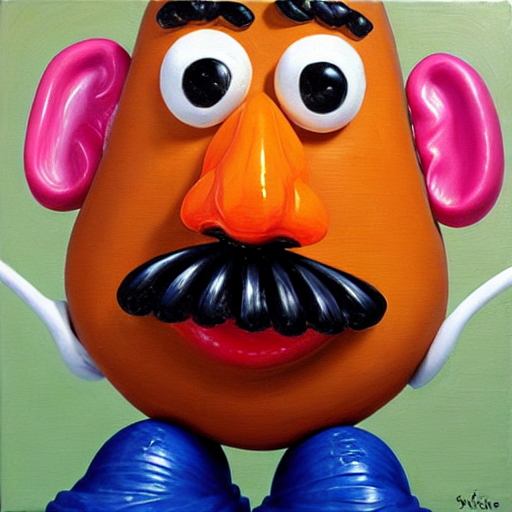

In [16]:
image

#### ***🧪 Laboratory: Exercises and Experiments***

To gain a deeper understanding of what is happening inside this “magic box” (pipeline), the tutorial encourages us to conduct three key experiments:

#### ***Experiment A: What happens if we omit the keyword*** `sks`***?***

- **Theoretical principle:** The DreamBooth method works by assigning a unique, previously unknown token to a new object (this particular toy) in the text dictionary - in this case `sks`.
- **Try changing the prompt to:** `"an abstract oil painting of mr potato head by picasso"` (without `sks`).
- **Expected result:** The model will generate some Mr. Potato because it knows this phrase from its original training on the Internet, but the **unique identity of the specific toy** from those 5 photos will be lost.

  0%|          | 0/50 [00:00<?, ?it/s]

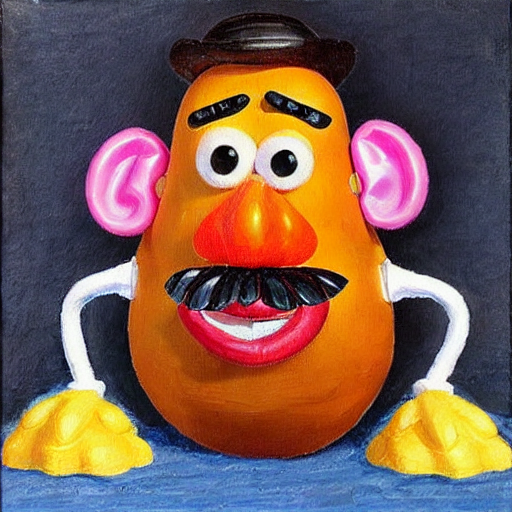

In [17]:
prompt = "an abstract oil painting of mr potato head by picasso"

image = pipe(
    prompt, 
    num_inference_steps=50, 
    guidance_scale=7.5
).images[0]

image

#### ***Experiment B: Bending the*** `num_inference_steps parameter`

- **Theoretical principle:** This parameter determines how many times in a row the neural network looks at the noise matrix and subtracts the estimated noise from it (number of denoising steps).
- **Try setting:** `num_inference_steps=10` or even `num_inference_steps=3`.
- **Expected result:** You'll find out how low you can go with the number of steps before the image turns into a blurry digital mush full of artifacts. The diffusion process simply takes time (steps) to extract fine details from the chaos.

  0%|          | 0/25 [00:00<?, ?it/s]

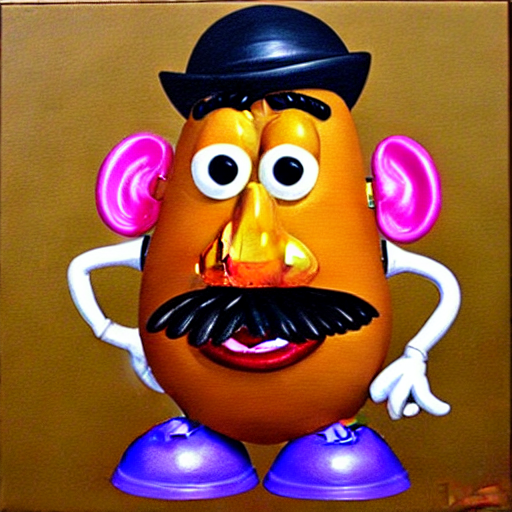

In [18]:
prompt = "an abstract oil painting of sks mr potato head by picasso"

image = pipe(
    prompt, 
    num_inference_steps=25, 
    guidance_scale=7.5
).images[0]

image

  0%|          | 0/5 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


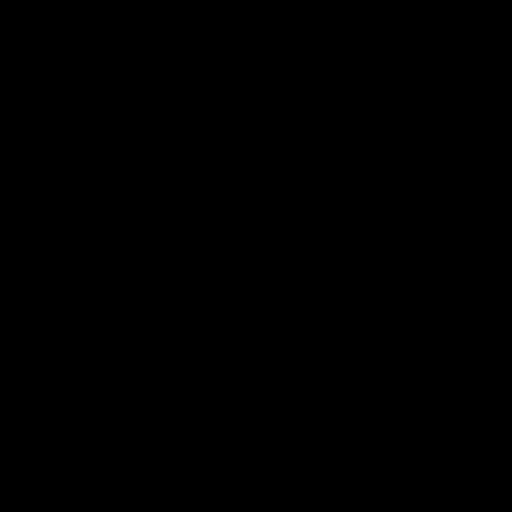

In [19]:
prompt = "an abstract oil painting of sks mr potato head by picasso"

image = pipe(
    prompt, 
    num_inference_steps=5, 
    guidance_scale=7.5
).images[0]

image

#### ***Experiment C: Playing with the*** `guidance_scale` ***parameter (CFG Scale)***

- **Theoretical principle:** This parameter (Classifier-Free Guidance) tells the model how tightly it should adhere to your textual input at the expense of its own "creative freedom".
- **Standard value:** `7.0` to `9.0` (ideal compromise).
- **Extreme down** (`1.0`–`3.0`): The model almost ignores the prompt, the image will be nice, but it will probably forget about the Picasso style.
- **Extreme Up** (`15.0` and above): The model will try to fulfill the text so literally that the image will start to have unnaturally overblown contrast, distorted colors, and ruined composition.

  0%|          | 0/50 [00:00<?, ?it/s]

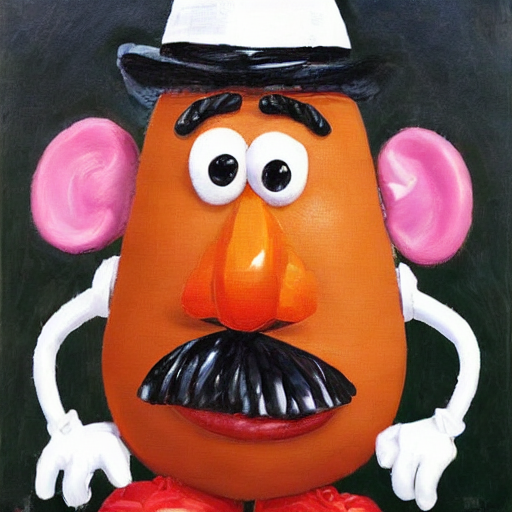

In [20]:
prompt = "an abstract oil painting of sks mr potato head by picasso"

image = pipe(
    prompt, 
    num_inference_steps=50, 
    guidance_scale=3.0
).images[0]

image

  0%|          | 0/50 [00:00<?, ?it/s]

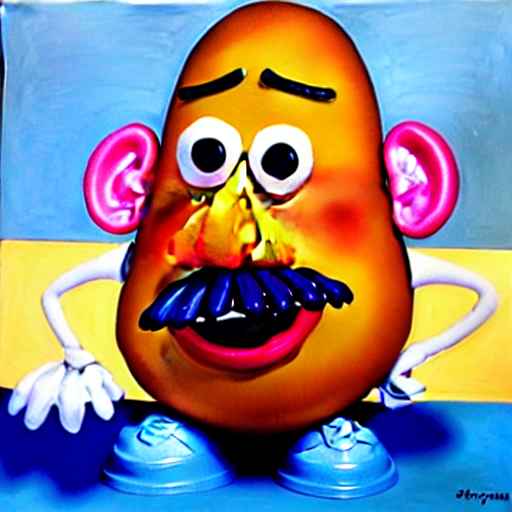

In [21]:
prompt = "an abstract oil painting of sks mr potato head by picasso"

image = pipe(
    prompt, 
    num_inference_steps=50, 
    guidance_scale=12.0
).images[0]

image